Se pide implementar un modelo de regresión lineal para predecir el precio de casas basándose en múltiples variables (pies cuadrados y número de habitaciones).

## Preparación de Datos y Normalización
Cargaremos los datos y aplicaremos normalización de características para asegurar la convergencia del descenso del gradiente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Carga de datos
data = pd.read_csv('ex1data2.txt', header=None, names=['Size', 'Bedrooms', 'Price'])
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)
m = len(y)

def normalize_features(X):
    #normalización usando Z-score para variables de entrada.
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalize_features(X)

#Añadimos columna de unos 
X_final = np.hstack([np.ones((m, 1)), X_norm])
theta_initial = np.zeros((X_final.shape[1], 1))

## Implementación del Modelo (Coste y Optimización)
Utilizaremos una implementación vectorizada que es mucho más rápida y limpia que usar bucles for sobre los ejemplos.

In [2]:
def compute_cost(X, y, theta):
    #Calculamos error cuadratico medio
    predictions = X @ theta
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors**2)
    return cost

def gradient_descent(X, y, theta, alpha, iterations):
    
    history = []
    
    for i in range(iterations):
        #Cálculo del gradiente vectorizado
        gradient = (1 / m) * (X.T @ (X @ theta - y))
        theta = theta - alpha * gradient
        
        #Guardamos el historial de coste
        history.append(compute_cost(X, y, theta))
        
    return theta, history

#Configuramos hiperparámetros
ALPHA = 0.1
ITERATIONS = 150

#fase de entrenemiento
theta_final, cost_history = gradient_descent(X_final, y, theta_initial, ALPHA, ITERATIONS)

## Evaluacion
Visualizamps como disminuye el coste para ver que tan bueno es el alpha que hemos seleccionado.

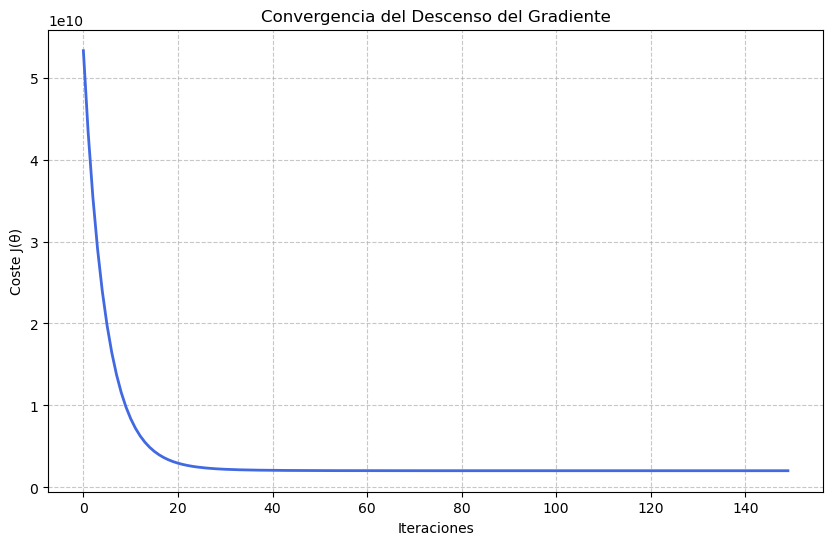

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history, color='royalblue', lw=2)
plt.title('Convergencia del Descenso del Gradiente')
plt.xlabel('Iteraciones')
plt.ylabel('Coste J(θ)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Y como podemos apreciar el modelo ha convergido muy rápidamente y a partir de las 20  iteraciones ya no puede seguir convergiendo.

## Predicciones con el Modelo Entrenado
Realizamos predicciones con datos nuevos para ver su eficacia

In [4]:

sample = np.array([1650, 3])

#Normalizamos
sample_norm = (sample - mu) / sigma


sample_final = np.append(1, sample_norm)
prediction = sample_final @ theta_final

print("Precio estimado para una casa de 1650 metros cuadrados y 3 hab: ", prediction[0])

Precio estimado para una casa de 1650 metros cuadrados y 3 hab:  293096.3563801559
